# Data Challenge 1 - Final Project

**Student:** Pham Duy Truong  
**Dataset:** Titanic (891 passengers, 12 features)  
**Model:** Random Forest Classifier  

**Requirement mark coverage:**
1. Dataset summerizing (20%)
2. Exploratory Data Analysis (20%)
3. Visualization (20%)
4. Model building and prediction (20%)
5. Hyperparameter tuning (20%)

---
## 1. Import libraries and dependencies

In [ ]:
#pip install pandas matplotlib seaborn datetime scikit-learn imbalanced-learn

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

---
## 2. Summarize the dataset

Load the Titanic CSV and explore its structure: shape, data types, statistics, and missing values.

In [86]:
path = 'https://raw.githubusercontent.com/lunarpham/data-challenge-final/refs/heads/main/titanic.csv'
df = pd.read_csv(path)

In [87]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [88]:
df.shape

(891, 12)

In [89]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [90]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


---
## 3. Exploratory Data Analysis and Visualization

### 3.1. Target Distribution (Survived)

Text(0.5, 1.0, 'Survival Distribution (0 = no, 1 = yes)')

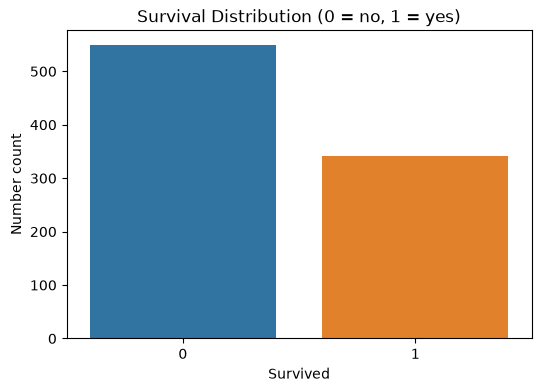

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.countplot(x = 'Survived', hue = 'Survived', data = df, ax = ax, legend = False)
ax.set_ylabel('Number count') 
ax.set_title('Survival Distribution (0 = no, 1 = yes)')

### 3.2. Survival by features (sex, age, embarked location)

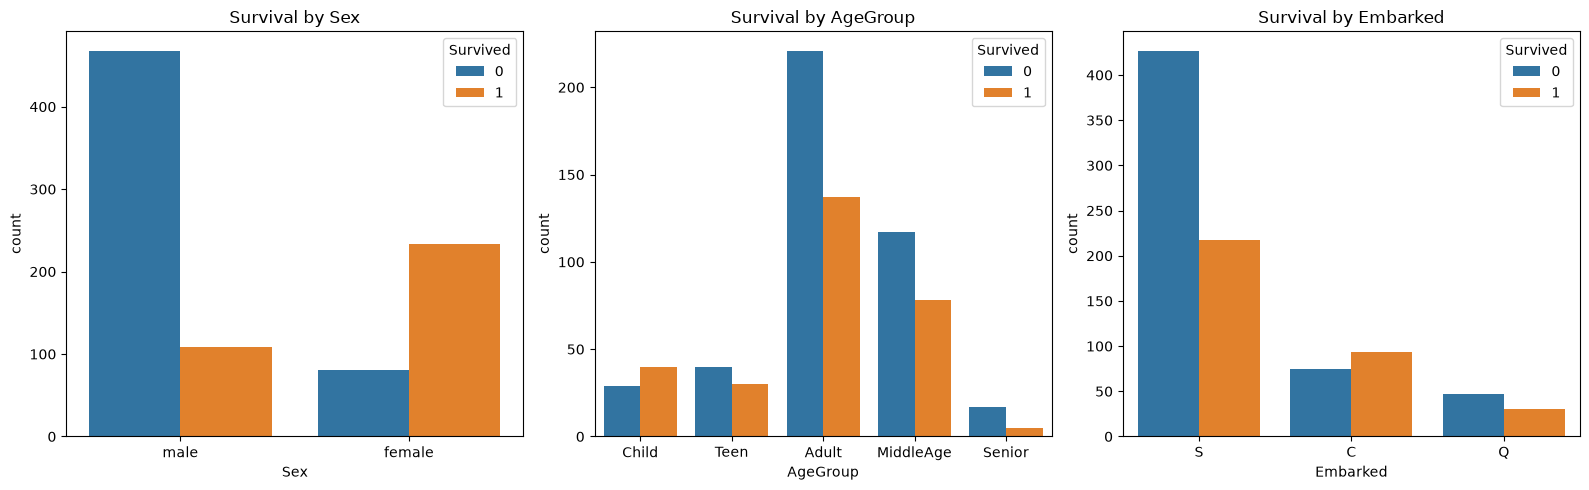

In [92]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior'])

features = ['Sex', 'AgeGroup', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feature in enumerate(features):
    sns.countplot(x=feature, hue='Survived', data=df, ax=axes[i])
    axes[i].set_title(f'Survival by {feature}')

plt.tight_layout()
plt.show()

Figure 1: Being female made you more likely to survive. Most men died, most women lived. This is the clearest, strongest pattern in the whole dataset, matching the historical "women and children first" evacuation policy back then or even nowadays.
 
Figure 2: Children were the only group where more people survived than died. This directly supports "children first" during evacuation.

Figure 3: People who boarded at Southampton mostly died. People who boarded at Cherbourg actually had better than 50/50 odds. Queenstown passengers mostly died too, similar to Southampton. It's hiddenly a proxy for wealth: Cherbourg had a much higher share of wealthy, first-class passengers, and wealthier passengers had better access to lifeboats because their cabins are at higher level while commoners had to stay at bottom level of the ship.

### 3.4. Fare Distribution by Pclass and Survival

<Axes: xlabel='Pclass', ylabel='Fare'>

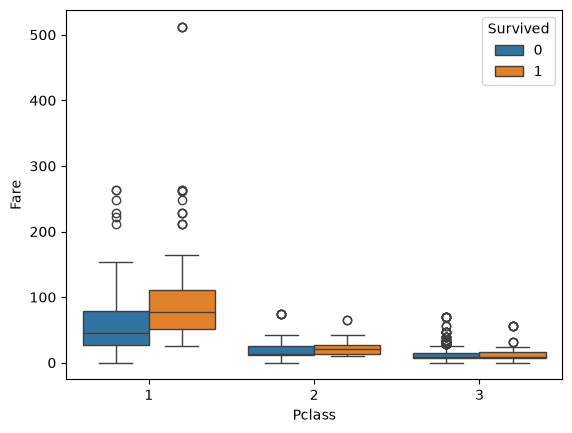

In [93]:
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=df)

Higher class = higher fare = better survival, all consistent with each other. As you move one by one from Pclass 1 to 3, both the fares paid and the survival rates drop sharply. This confirms Pclass and Fare are capturing largely the same underlying thing: wealth/social status. Within every class, survivors paid more than non-survivors. Look at each Pclass group individually, the orange box sits consistently higher than the blue box, even within the same class. Even within 1st class, the passengers who paid more for their tickets tended to survive more than those who paid less. Same pattern holds in 2nd and 3rd class, just at a smaller scale.

### 3.5. Correlation Heatmap

<Axes: >

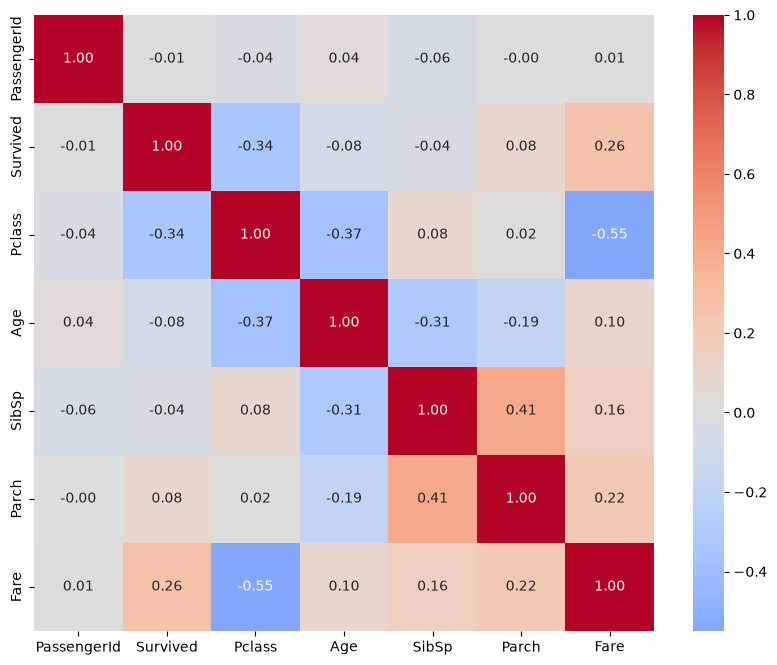

In [94]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')

Pclass (Ticket Class) & Fare => -0.55: The strongest negative connection. Lower class number (like 1st class) means a higher ticket price, while a higher class number (like 3rd class) means a lower ticket price.

Survived & Pclass => -0.34: Negative connection. It means that passengers in higher-numbered classes (like 3rd class) were less likely to survive compared to those in 1st class.

Survived & Fare => 0.26: Positive connection. It tells us that people who paid a higher ticket price had a better chance of surviving.

SibSp (Siblings/Spouses) & Parch (Parents/Children) => 0.41: Passengers who traveled with siblings or a spouse were also very likely to be traveling with their parents or children.

Pclass & Age => -0.37:  Negative connection. Passengers in the higher-numbered classes (3rd class) tended to be younger, while 1st class passengers tended to be older.

---
## 4. Data cleansing

**Issues to fix:**
- `Age`: ~20% missing => extract titles from their names so we can likely guess thier age based on the same pattern
- `Cabin`: 77% missing => convert to yes or no feature then drop
- `Embarked`: 2 nulls => fill with the most overwhelming value
- Drop columns not useful for prediction: `PassengerId`, `Name`, `Ticket`, `Name`

In [95]:
def missing_cols(df):
    total = 0
    for col in df.columns:
        missing_vals = df[col].isnull().sum()
        # mean = sum / total
        pct = df[col].isnull().mean() * 100 
        if missing_vals != 0:
          print('{} => {} [{}%]'.format(col, df[col].isnull().sum(), round(pct, 2)))
        total += missing_vals
    
    if total == 0:
        print("No missing values left!")

In [96]:
missing_cols(df)

Age => 177 [19.87%]
Cabin => 687 [77.1%]
Embarked => 2 [0.22%]
AgeGroup => 177 [19.87%]


### 4.1. Handle missing ages

In [97]:
#There is nearly 20% of missing age values so we need to fill them
#Age can be predicted by titles extracted from their names
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')
print(df['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


### 4.2. Extract title from name

In [98]:
title_map = {
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Lady': 'Rare', 
    'Countess': 'Rare', 
    'Capt': 'Rare', 
    'Col': 'Rare',
    'Don': 'Rare',
    'Dr': 'Rare',
    'Major': 'Rare',
    'Rev': 'Rare',
    'Sir': 'Rare',
    'Jonkheer': 'Rare',
    'Dona': 'Rare',
    'the Countess': 'Rare'
}
df['Title'] = df['Title'].replace(title_map)
print(df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [99]:
df_encoded = pd.get_dummies(df, columns=['Title'], drop_first=False)

In [100]:
title_cols = [c for c in df_encoded.columns if c.startswith('Title_')]
features = ['Age', 'Pclass', 'SibSp', 'Parch', 'Fare'] + title_cols

scaler = StandardScaler()
scaled = scaler.fit_transform(df_encoded[features])

imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(scaled)

imputed_unscaled = scaler.inverse_transform(imputed)
df['Age'] = imputed_unscaled[:, features.index('Age')]

### 4.4. Verify age imputation

If it's 0 then it's successful

In [101]:
print(df['Age'].isnull().sum()) 

0


In [102]:
df.groupby('Title')['Age'].mean()

Title
Master     4.620950
Miss      21.342432
Mr        32.485687
Mrs       35.747619
Rare      45.652174
Name: Age, dtype: float64

In [103]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,MiddleAge,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,Mr
5,6,0,3,"Moran, Mr. James",male,26.2,0,0,330877,8.4583,NaN,Q,NaN,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,MiddleAge,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Child,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Adult,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Teen,Mrs


### 4.5. Fill missing embarked locations with the most value

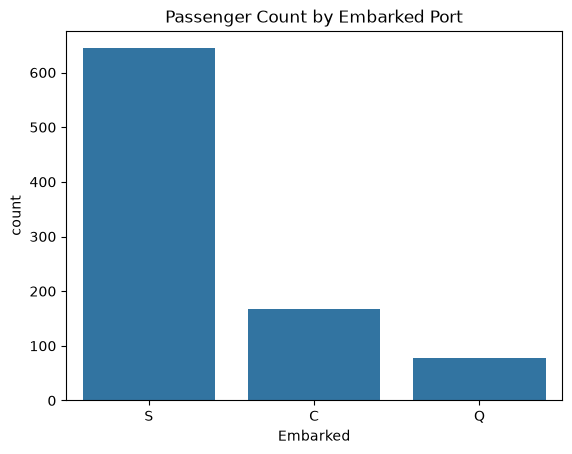

In [104]:
sns.countplot(x='Embarked', data=df, order=df['Embarked'].value_counts().index)
plt.title('Passenger Count by Embarked Port')
plt.show()

In [105]:
# Check for missing embarked value
print(df['Embarked'].isnull().sum())

2


In [106]:
#Since S is the most value, we can just fill those 2 missing values with it
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 
print(df['Embarked'].isnull().sum())

0


### 4.6. Drop unnecessary columns and convert Cabin column to boolean type

In [107]:
df['HasCabin'] = df['Cabin'].notna().astype(int)
df =  df.drop(columns=['PassengerId', 'Ticket', 'Name', 'Cabin', 'AgeGroup']).copy()
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,Mr,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,0
5,0,3,male,26.2,0,0,8.4583,Q,Mr,0
6,0,1,male,54.0,0,0,51.8625,S,Mr,1
7,0,3,male,2.0,3,1,21.0750,S,Master,0
8,1,3,female,27.0,0,2,11.1333,S,Mrs,0
9,1,2,female,14.0,1,0,30.0708,C,Mrs,0


### 4.7. Verifying no missing value left

In [108]:
missing_cols(df)

No missing values left!


---
## 5. Feature encoding

Convert categorical columns to numerical:
- `Sex` => Label Encoding (binary: female=0, male=1)
- `Embarked` => One-Hot Encoding (nominal: S, C, Q)
- `Title` => One-Hot Encoding (nominal: Mr, Mrs, Miss, etc.)

### 5.1. Label encode `Sex`

In [109]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # female=0, male=1

### 5.2. One-Hot encode for `Embarked` and `Title`

In [110]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df = pd.get_dummies(df, columns=['Title'], drop_first=True)

In [111]:
print(df.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
HasCabin        int64
Embarked_Q       bool
Embarked_S       bool
Title_Miss       bool
Title_Mr         bool
Title_Mrs        bool
Title_Rare       bool
dtype: object


In [112]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22.0,1,0,7.2500,0,False,True,False,True,False,False
1,1,1,0,38.0,1,0,71.2833,1,False,False,False,False,True,False
2,1,3,0,26.0,0,0,7.9250,0,False,True,True,False,False,False
3,1,1,0,35.0,1,0,53.1000,1,False,True,False,False,True,False
4,0,3,1,35.0,0,0,8.0500,0,False,True,False,True,False,False


---
## 6. Feature selection and scaling

- Use `SelectKBest` with chi-squared test to rank features
- Scale numerical features (`Age`, `Fare`, `SibSp`, `Parch`) with `StandardScaler`

### 6.1. Separate features (X) and target (y) + feature selection

In [119]:
X = df.drop('Survived', axis=1)
y = df['Survived']

selector = SelectKBest(score_func=chi2, k='all')  # use f_classif if features have negatives
selector.fit(X, y)
scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
print(scores.sort_values('Score', ascending=False))

       Feature        Score
5         Fare  4518.319091
10    Title_Mr   112.805785
1          Sex    92.702447
11   Title_Mrs    89.474177
9   Title_Miss    79.531749
6     HasCabin    68.997412
0       Pclass    30.873699
2          Age    25.152233
4        Parch    10.097499
8   Embarked_S     5.489205
3        SibSp     2.581865
12  Title_Rare     0.126121
7   Embarked_Q     0.010847


### 6.2. Train-Test split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target distribution:\n{y_train.value_counts(normalize=True)}')

Train: (712, 13), Test: (179, 13)
Train target distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


### 6.3. Scale numerical features

In [121]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']  # adjust based on your features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
90,3,1,-0.071874,-0.483641,-0.469333,-0.512213,0,False,True,False,True,False,False
551,2,1,-0.215701,-0.483641,-0.469333,-0.109805,0,False,True,False,True,False,False
192,3,0,-0.791009,0.494632,-0.469333,-0.516603,0,False,True,True,False,False,False
95,3,1,-0.122213,-0.483641,-0.469333,-0.512213,0,False,True,False,True,False,False
668,3,1,0.934916,-0.483641,-0.469333,-0.512213,0,False,True,False,True,False,False


---
## 7. Handling imbalanced data

The dataset is imbalanced (~62% died vs ~38% survived).  
Apply SMOTE on the training data only to balance classes.

In [122]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_resampled).value_counts().to_dict()}')

Before SMOTE: {0: 439, 1: 273}
After SMOTE:  {0: 439, 1: 439}


---
## 8. Build Random Forest model and evaluate

Train a Random Forest classifier on SMOTE-resampled data, then evaluate on original test set.

Reason to choose Random Forest: It's an excellent choice for the Titanic dataset because it relies on the "wisdom of the crowd" to prevent overfitting. By building hundreds of randomized decision trees and averaging their votes, it creates a robust model that avoids merely memorizing noisy data. Additionally, it easily handles the dataset's messy mix of numerical and categorical information without complex preprocessing, delivers high accuracy right out of the box, and provides clear, built-in explainability so you can see exactly which features drove its final predictions.

### 8.1. Train and predict

In [123]:
rf = RandomForestClassifier(n_estimators=100, random_state=30)
rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

### 8.2. Classification report and ROC-AUC

In [124]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       110
           1       0.75      0.78      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

ROC-AUC Score: 0.8524


### 8.3. Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

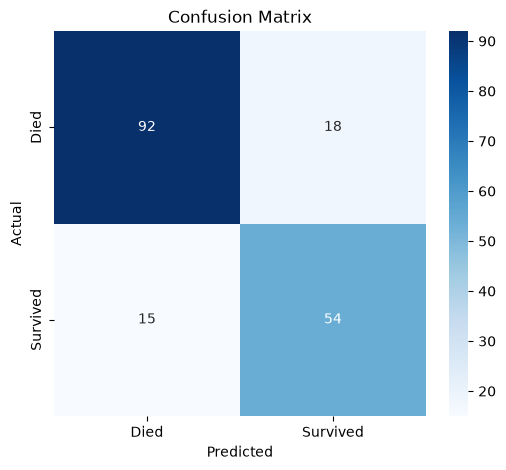

In [125]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

- 92 times: The passenger died, and the model correctly predicted they died (True Negative).
- 54 times: The passenger survived, and the model correctly predicted they survived (True Positive).
- 18 times: The passenger actually died, but the model incorrectly predicted they survived (False Positive).
- 15 times: The passenger actually survived, but the model incorrectly predicted they died (False Negative).

### 8.4 ROC Curve

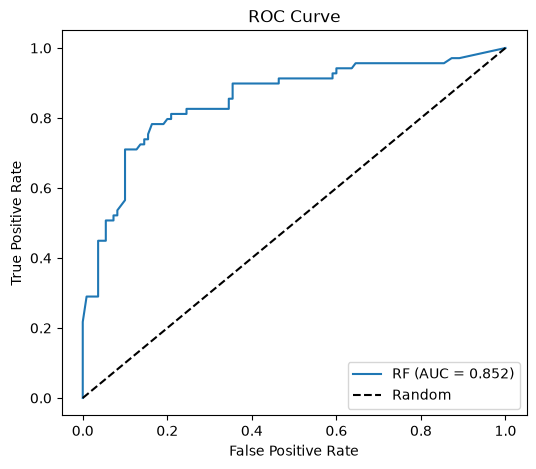

In [126]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'RF (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

AUC 0.852 is a strong score! It means that if you pick one random person who survived and one random person who died, there is an 85.2% chance your model will correctly tell them apart.

### 8.5 Feature importance

Text(0.5, 0, 'Importance')

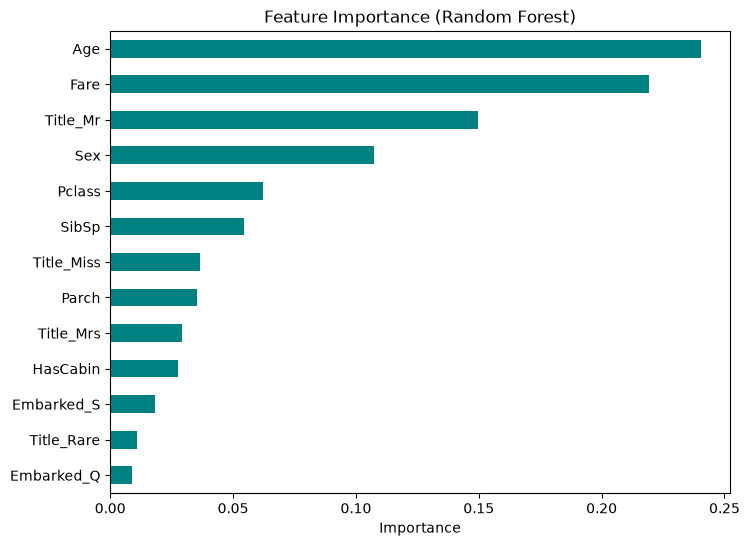

In [127]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6), color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')

In [128]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(perm_importances)

Pclass        7.709497e-02
Age           4.748603e-02
Fare          4.525140e-02
Title_Mr      4.189944e-02
Sex           2.849162e-02
SibSp         2.849162e-02
Title_Mrs     1.620112e-02
Title_Miss    1.508380e-02
HasCabin      1.005587e-02
Embarked_S    1.005587e-02
Embarked_Q    5.586592e-04
Title_Rare    1.110223e-17
Parch        -3.910615e-03
dtype: float64


---
## 9. Hyperparameter tuning

Use `GridSearchCV` with `StratifiedKFold` to find optimal Random Forest parameters.

In [132]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 5, 10, 15],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced'],
    'rf__max_features': ['sqrt', 'log2', None],
    'rf__criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print the best results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Best parameters: {'rf__class_weight': None, 'rf__criterion': 'entropy', 'rf__max_depth': 5, 'rf__max_features': None, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Best ROC-AUC score: 0.8791


In [134]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 3. Print the final performance metrics
print('--- FINAL TUNED MODEL EVALUATION ---')
print(classification_report(y_test, y_pred))
print(f'Final Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}')

--- FINAL TUNED MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       110
           1       0.73      0.77      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Final Test ROC-AUC Score: 0.8617


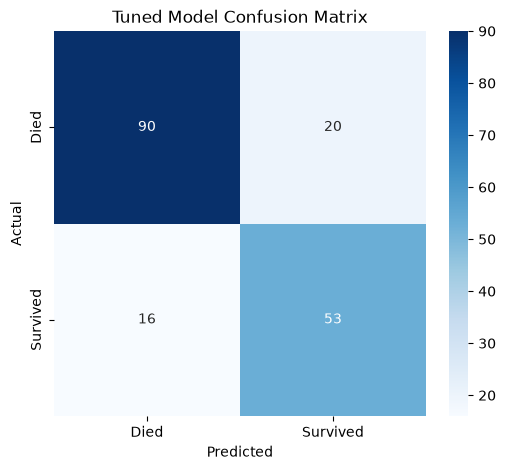

In [136]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Model Confusion Matrix')
plt.show()

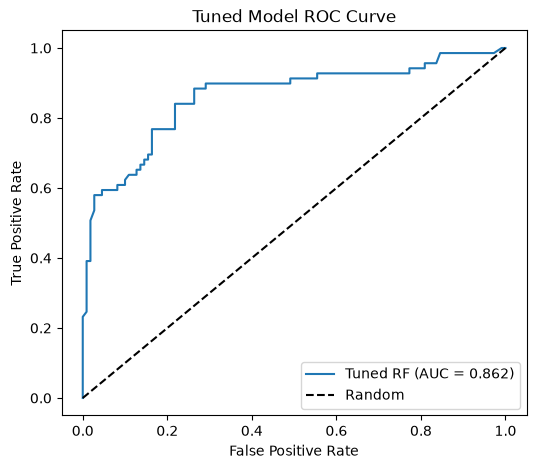

In [137]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Tuned RF (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned Model ROC Curve')
plt.legend()
plt.show()